In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('IMDb_Top_700_Movies_2026.xlsx')

# Inspect the first few rows
df.head()

,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,1993,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195


In [3]:
# 1. View the first 5 rows
print("First 5 Rows")
display(df.head())

# 2. Check dataset shape and data types
print("\n Dataset Summary")
df.info()

# 3. Check exact column names
print("\nColumn Names")
print(df.columns.tolist())

First 5 Rows


,Rank,Title,Year,Genre(s),Director,Main Actor(s),Country,IMDb Rating,Votes,Runtime (mins)
0,1,The Shawshank Redemption,1994,Drama,Frank Darabont,Tim Robbins|Morgan Freeman|Bob Gunton,DK|AT,9.3,3219532,142
1,2,The Godfather,1972,Crime|Drama,Francis Ford Coppola,Marlon Brando|Al Pacino|James Caan,DK|AT,9.2,2244476,175
2,3,The Dark Knight,2008,Crime|Thriller,Christopher Nolan,Christian Bale|Heath Ledger|Aaron Eckhart,DK|LV,9.1,3205233,152
3,4,The Lord of the Rings: The Return of the King,2003,Adventure|Drama|Fantasy,Peter Jackson,Elijah Wood|Viggo Mortensen|Ian McKellen,DK|MK,9.0,2181911,201
4,5,Schindler's List,1993,Biography|Drama|History,Steven Spielberg,Liam Neeson|Ralph Fiennes|Ben Kingsley,DK|LV,9.0,1595992,195



 Dataset Summary
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rank            700 non-null    int64  
 1   Title           700 non-null    object 
 2   Year            700 non-null    int64  
 3   Genre(s)        700 non-null    object 
 4   Director        700 non-null    object 
 5   Main Actor(s)   690 non-null    object 
 6   Country         700 non-null    object 
 7   IMDb Rating     700 non-null    float64
 8   Votes           700 non-null    int64  
 9   Runtime (mins)  700 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 54.8+ KB

Column Names
['Rank', 'Title', 'Year', 'Genre(s)', 'Director', 'Main Actor(s)', 'Country', 'IMDb Rating', 'Votes', 'Runtime (mins)']


In [4]:
# Clean column names (lowercase, remove parentheses, replace spaces with underscores)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

print("Updated Clean Column Names:")
print(df.columns.tolist())

Updated Clean Column Names:
['rank', 'title', 'year', 'genres', 'director', 'main_actors', 'country', 'imdb_rating', 'votes', 'runtime_mins']


In [5]:
# 1. Feature Engineering: Add 'decade' column
df['decade'] = (df['year'] // 10 * 10).astype(int).astype(str) + 's'

# 2. View Numerical Summary Statistics
print("--- Numerical Summary Statistics ---")
display(df[['imdb_rating', 'votes', 'runtime_mins', 'year']].describe())

# 3. Unnest Genres for Individual Breakdown
genres_df = df.assign(genres=df['genres'].str.split('|')).explode('genres')
genres_df['genres'] = genres_df['genres'].str.strip()

# 4. Genre Breakdown Summary
genre_summary = (
    genres_df.groupby('genres')
    .agg(
        movie_count=('title', 'count'),
        avg_rating=('imdb_rating', 'mean'),
        avg_votes=('votes', 'mean')
    )
    .sort_values(by='movie_count', ascending=False)
)

print("\n--- Top Genres Overview ---")
display(genre_summary.head(10))

--- Numerical Summary Statistics ---


,imdb_rating,votes,runtime_mins,year
count,700.000000,7.000000e+02,700.000000,700.000000
mean,8.000143,5.330973e+05,127.360000,1998.038571
std,0.316657,4.692722e+05,29.101895,21.347254
min,7.500000,5.196400e+04,68.000000,1921.000000
25%,7.800000,1.982610e+05,106.000000,1989.000000
50%,8.000000,3.988475e+05,123.000000,2004.000000
75%,8.200000,7.285130e+05,143.000000,2013.250000
max,9.300000,3.219532e+06,321.000000,2026.000000



--- Top Genres Overview ---


,movie_count,avg_rating,avg_votes
genres,,,
Drama,473,8.028330,480990.642706
Adventure,176,7.980682,659272.119318
Action,160,7.923750,594759.200000
Crime,156,8.014744,549694.294872
Comedy,149,7.930201,479026.791946
Thriller,106,7.920755,567073.471698
Mystery,80,7.981250,513971.350000
Biography,78,8.037179,426798.153846
Romance,72,7.963889,416447.027778


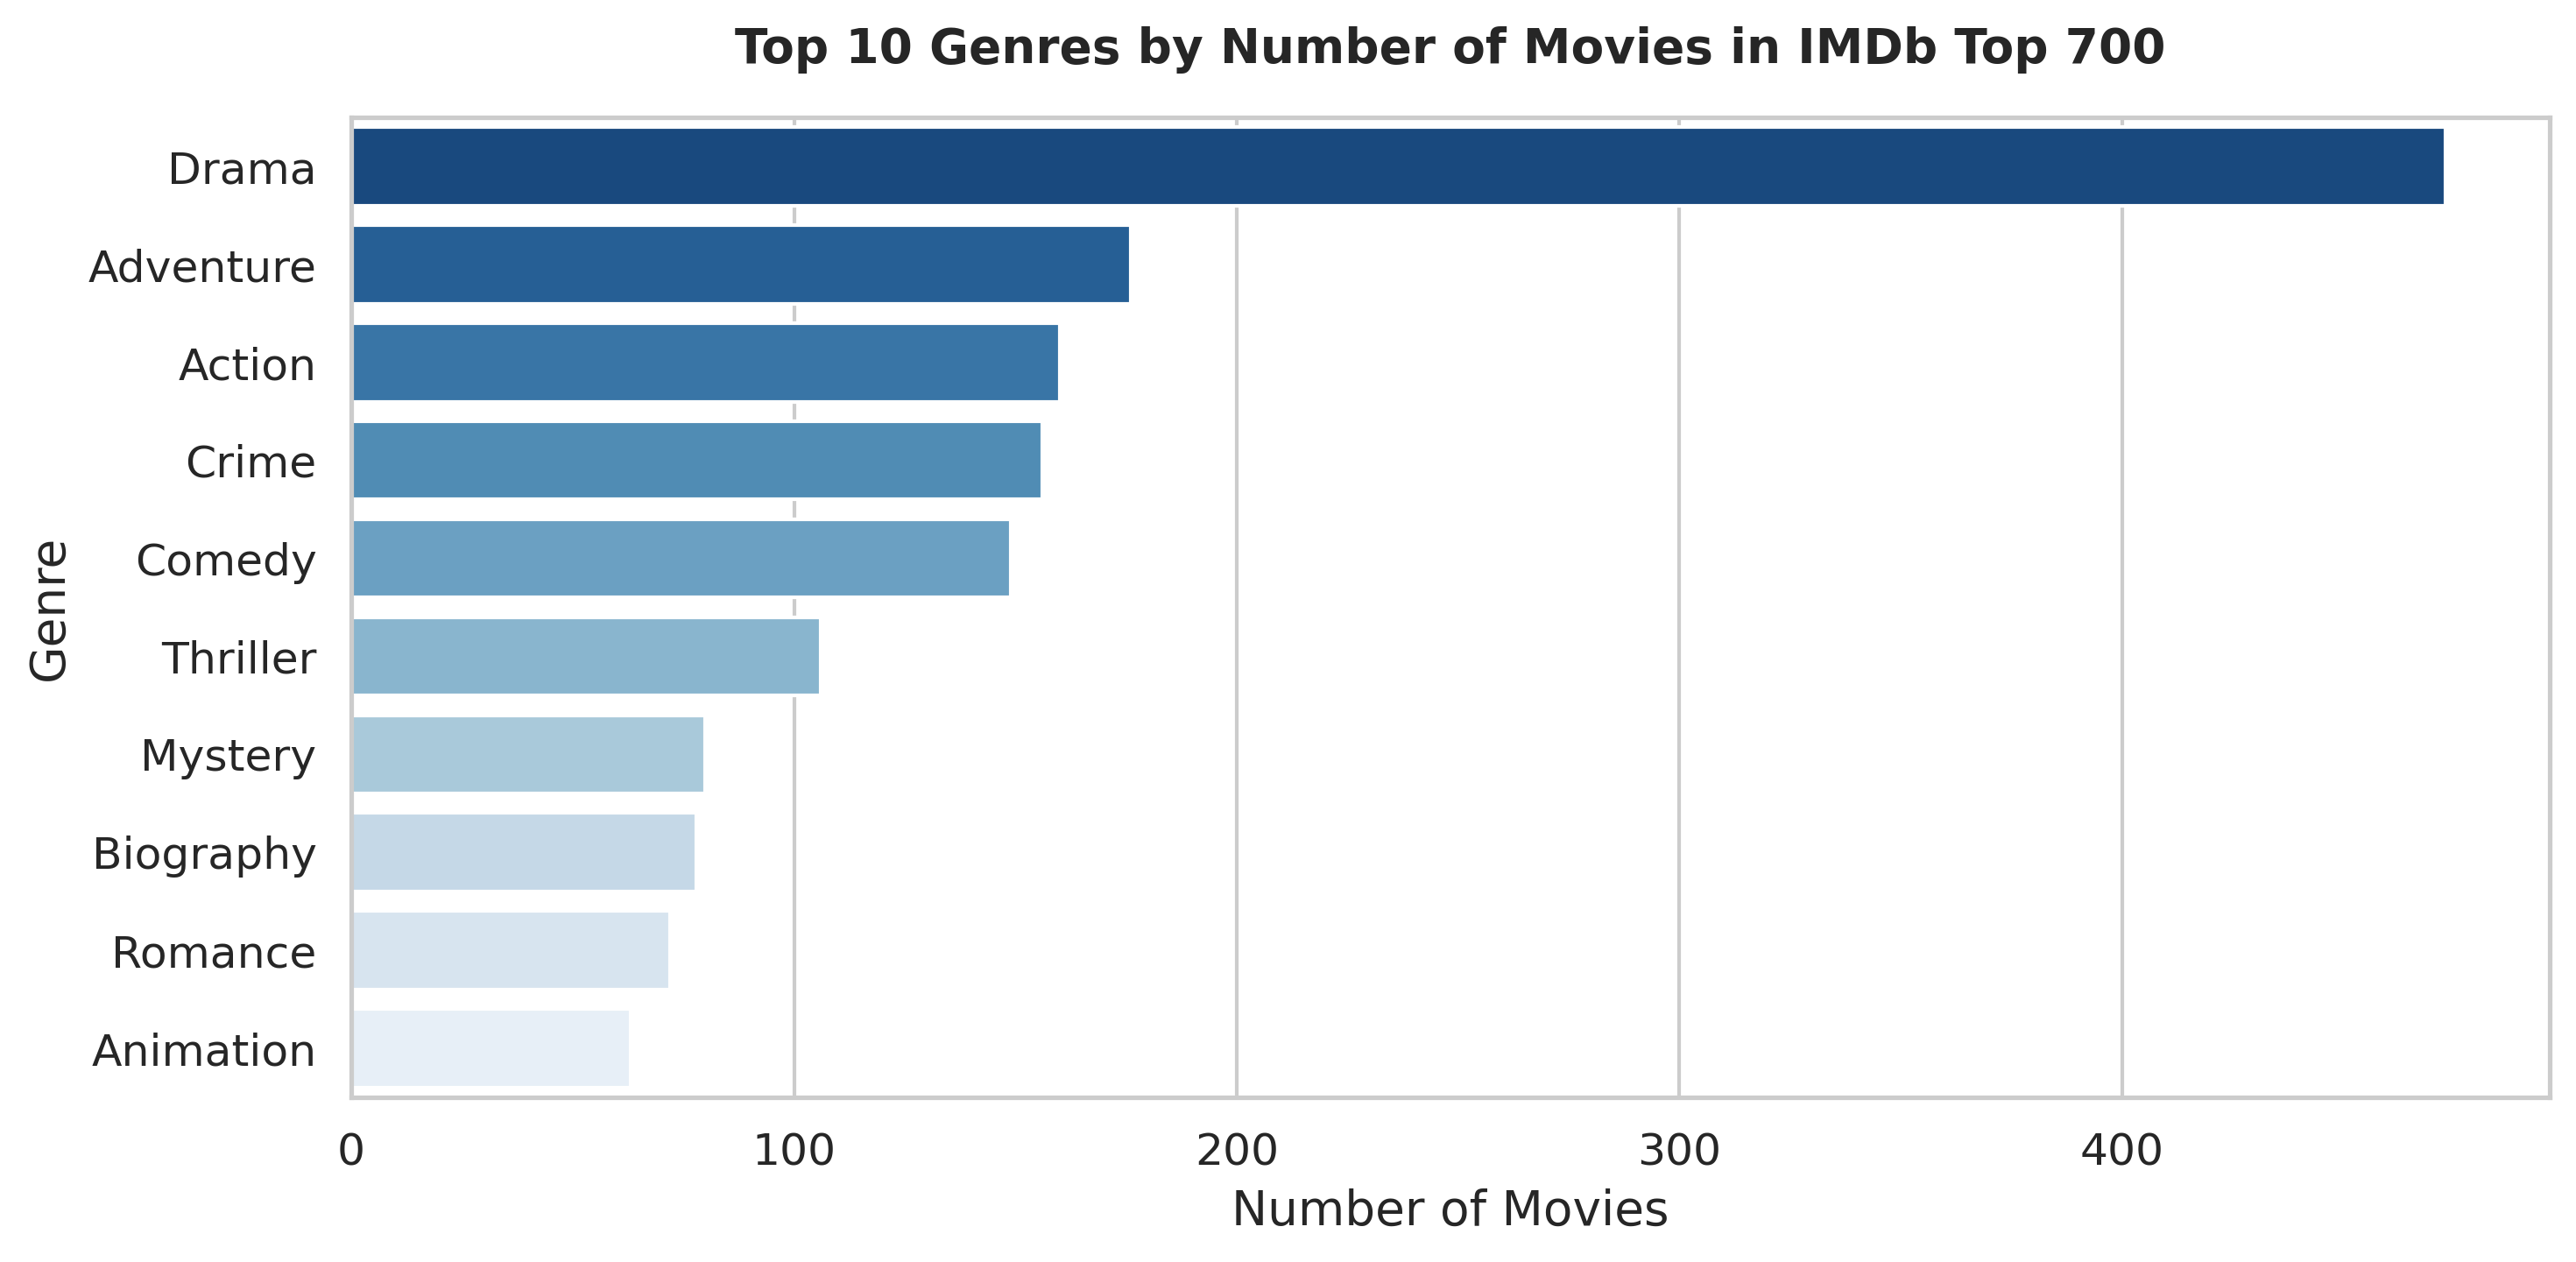

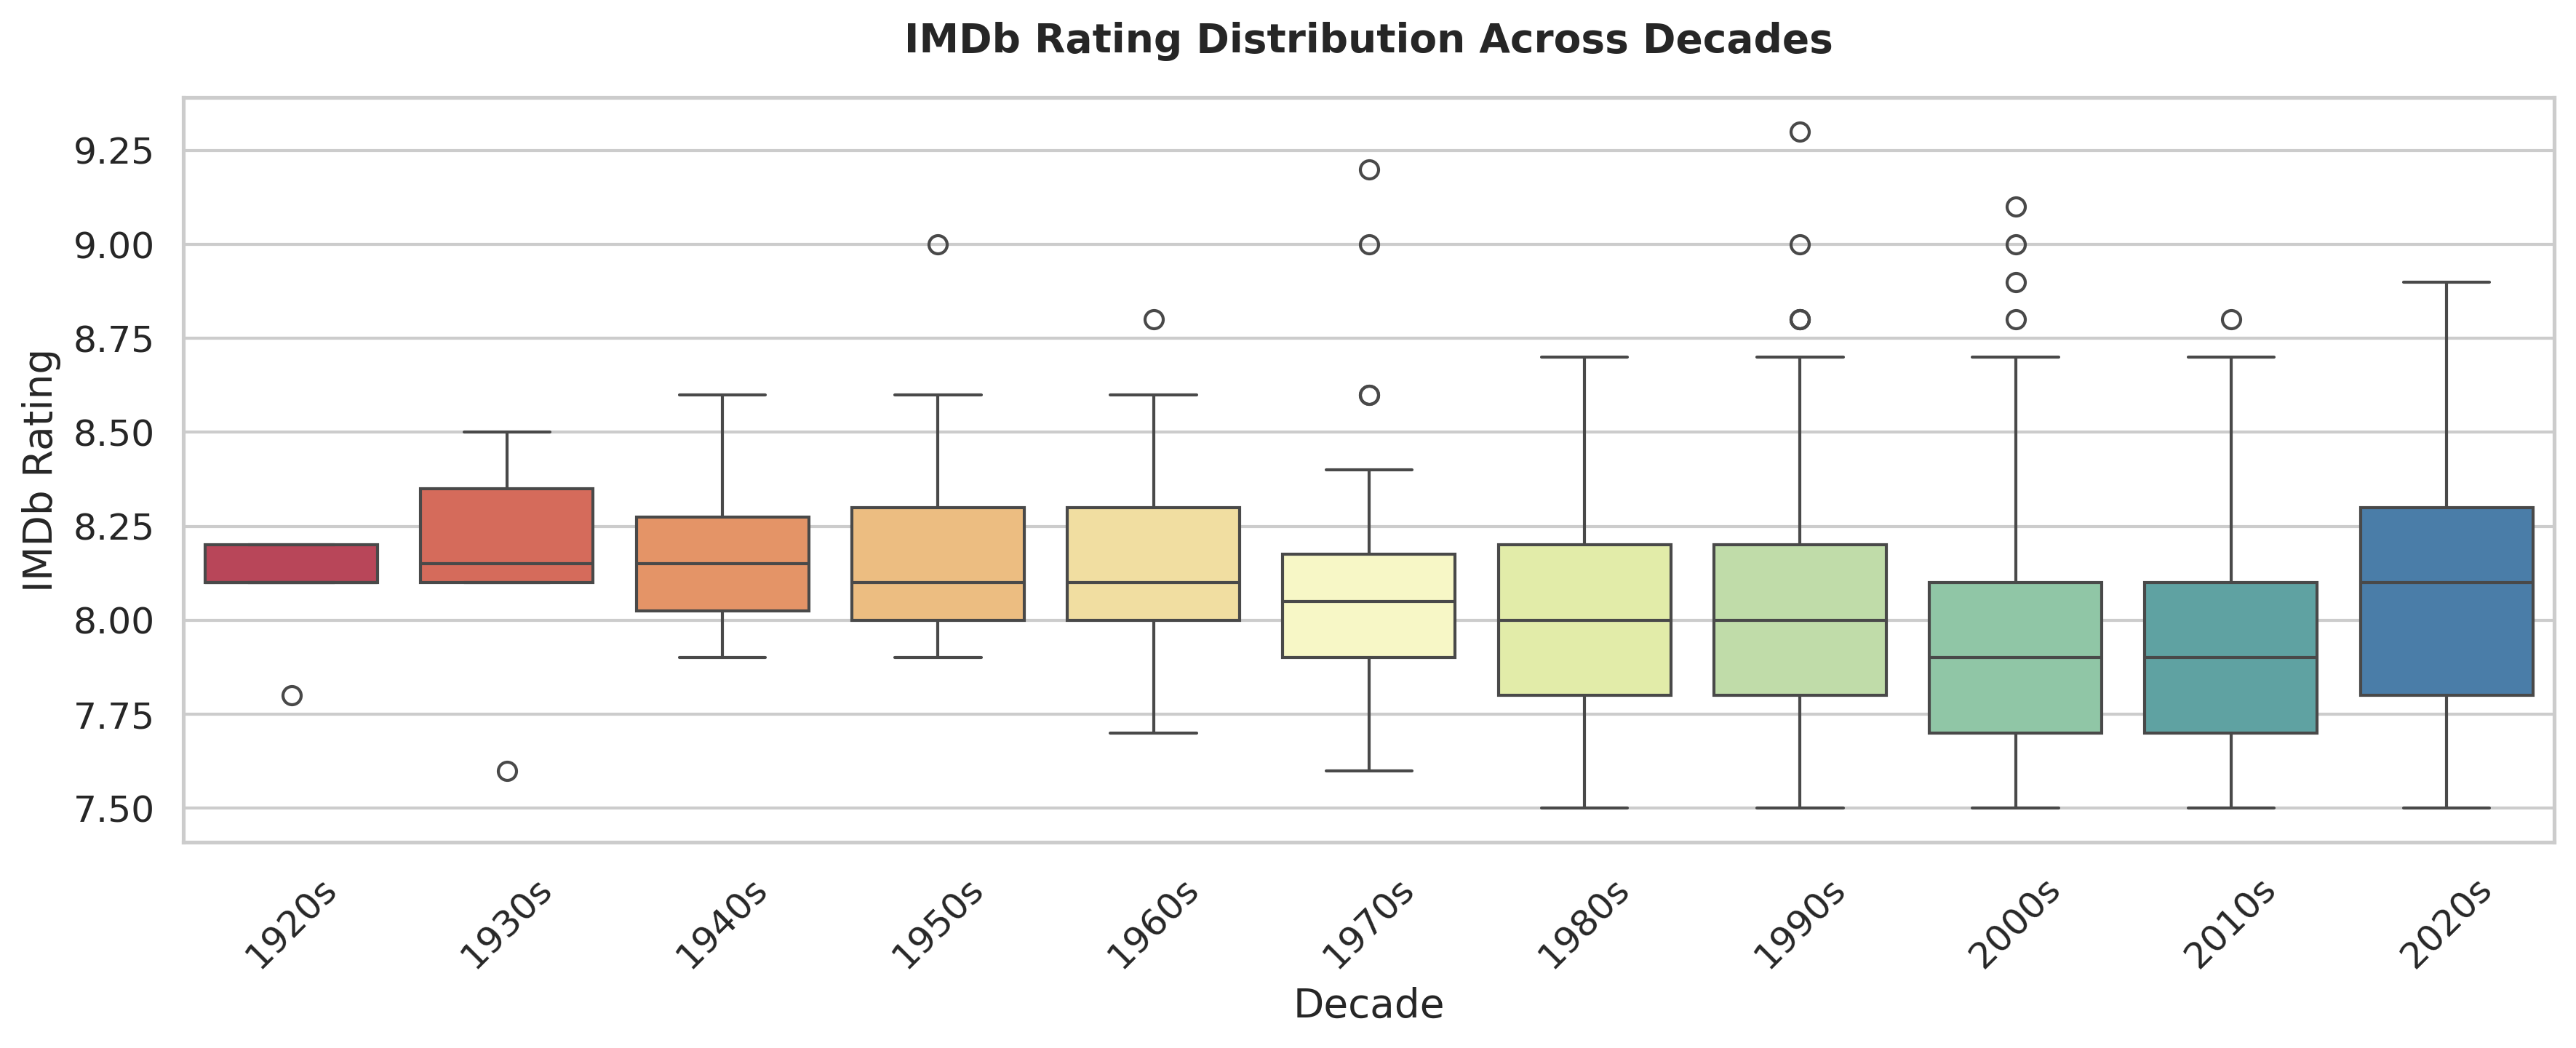

Visualizations generated and saved in 'visualisations/' folder


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create visualisations folder if it doesn't exist
os.makedirs('visualisations', exist_ok=True)

# Set visual aesthetic
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 300

# Chart 1: Top 10 Genres by Movie Count
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=genre_summary.head(10).reset_index(),
    x='movie_count',
    y='genres',
    hue='genres',
    legend=False,
    palette='Blues_r'
)
plt.title('Top 10 Genres by Number of Movies in IMDb Top 700', pad=15, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.tight_layout()

# Save Chart 1
plt.savefig('visualisations/top_10_genres.png', bbox_inches='tight')
plt.show()

# Chart 2: Ratings vs. Decades Boxplot
plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df.sort_values('decade'),
    x='decade',
    y='imdb_rating',
    hue='decade',
    legend=False,
    palette='Spectral'
)
plt.title('IMDb Rating Distribution Across Decades', pad=15, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('IMDb Rating')
plt.xticks(rotation=45)
plt.tight_layout()

# Save Chart 2
plt.savefig('visualisations/ratings_by_decade.png', bbox_inches='tight')
plt.show()

print("Visualizations generated and saved in 'visualisations/' folder")

In [10]:
# Save clean dataset
df.to_csv('cleaned_imdb_movies.csv', index=False)
print(" 'cleaned_imdb_movies.csv' exported successfully")

 'cleaned_imdb_movies.csv' exported successfully
